In [5]:
import sys
sys.path.append("..")


# How to create an experiment


## Sustainbaility profiles of data centers

#### Grid data

The first step is to download grid data. Note that since this software uses electricitymap's free API, it is possible to download grid data referred to the 24h preceding the API call.

To get an API key, visit https://www.electricitymaps.com/pricing. Once you have your API key, paste it as the value for the variable ELECTRICITYMAPS_API_TOKEN in tokens.py.

Run the the file src/preprocessing/get_grid_data.py to download the grid data for all the regions of the datacenters listed in the files located in the reports folder.

In [ ]:
import src.preprocessing.get_grid_data as grid_data

grid_data.get_grid_data()

This step has generated the folder d_i-d_f/raw in data/experiments where d_f is the current datetime and d_i is 24h ahead. for each datacenter there is a folder "provider_city/energy_mix" containing energy mix data. Namely, api.json contains raw data from API, historica.csv contains source mix data relevant to the experiment and forecast.csv contains noised data to mimic forecast energy mix based on historical data and electricity map reported error of their forecast algorithm. 



Now you can set up d_i and d_f in config file

Example: 
../data/experiments/2025-04-21T11:00:00.000Z-2025-04-22T10:00:00.000Z
-->
d_i = "2025-04-21T11:00:00.000Z"
d_f = "2025-04-22T10:00:00.000Z"


#### Weather data and reports
Once grid data is downloaded, sustainability profiles can be pre-computes.

Note that this software uses Visual crossing's free API. To get an API key visit https://www.visualcrossing.com/weather-api/. Once you have your API key, paste it as the value for the variable VISUALCROSSING_API_TOKEN in src/tokens.py. Note that some query limitations apply.


In [ ]:
import src.preprocessing.region_preprocessing as region_preprocessing

region_preprocessing.preprocess("aws")

# if you do not want to change config file
#region_preprocessing.preprocess("aws", init_time="2025-04-21T11:00:00.000Z", end_time="2025-04-22T10:00:00.000Z")


## Job requests

### Scenario 1: Spark traces
This sceario is based on real traces of spark workloads executed using AWS. We consider publicly available traces 
-> link to scout dataset

#### Mapping traces 

Each trace is used to generate a "realistic" request for our simulation.

In [1]:
import pandas as pd
import numpy as np
from numpy.polynomial.polynomial import Polynomial
import matplotlib.pyplot as plt


In [2]:
def get_arrival_time_distribution(df: pd.DataFrame) -> (Polynomial, np.ndarray, np.ndarray, float):
    df['arrival_time'] = pd.to_datetime(df['arrival_time']).dt.tz_localize('UTC')
    df['hour'] = df['arrival_time'].dt.hour
    df['day'] = df['arrival_time'].dt.date

    hourly_distribution = df.groupby(['day', 'hour']).size().groupby('hour').mean()
    # Extract x (hour) and y (average number of jobs) values
    x = hourly_distribution.index
    y = hourly_distribution.values

    df.drop(columns=['hour', 'day'], inplace=True)

    # Fit a polynomial curve (e.g., degree 5)
    coefficients = np.polyfit(x, y, 5)
    polynomial = np.poly1d(coefficients)

    mae = np.mean(np.abs(y - polynomial(x)))
   
   
    return polynomial, x, y, mae

def sample(model, mae, x_fit) -> np.ndarray:
    std_dev = mae * (1/np.sqrt(2/np.pi))
    noise = np.random.normal(0, std_dev, size=x_fit.shape)
    s = model(x_fit) + noise

    return [int(n) for n in s]

In [6]:
import src.utils as utils
import src.config as config
timestamps = utils.get_timestamps(config.dt_i, config.dt_f, config.step)

In [7]:
timestamps_map = {
    date.hour : date
    for date in timestamps
}

In [8]:
timestamps_map

{11: datetime.datetime(2025, 4, 21, 11, 0),
 12: datetime.datetime(2025, 4, 21, 12, 0),
 13: datetime.datetime(2025, 4, 21, 13, 0),
 14: datetime.datetime(2025, 4, 21, 14, 0),
 15: datetime.datetime(2025, 4, 21, 15, 0),
 16: datetime.datetime(2025, 4, 21, 16, 0),
 17: datetime.datetime(2025, 4, 21, 17, 0),
 18: datetime.datetime(2025, 4, 21, 18, 0),
 19: datetime.datetime(2025, 4, 21, 19, 0),
 20: datetime.datetime(2025, 4, 21, 20, 0),
 21: datetime.datetime(2025, 4, 21, 21, 0),
 22: datetime.datetime(2025, 4, 21, 22, 0),
 23: datetime.datetime(2025, 4, 21, 23, 0),
 0: datetime.datetime(2025, 4, 22, 0, 0),
 1: datetime.datetime(2025, 4, 22, 1, 0),
 2: datetime.datetime(2025, 4, 22, 2, 0),
 3: datetime.datetime(2025, 4, 22, 3, 0),
 4: datetime.datetime(2025, 4, 22, 4, 0),
 5: datetime.datetime(2025, 4, 22, 5, 0),
 6: datetime.datetime(2025, 4, 22, 6, 0),
 7: datetime.datetime(2025, 4, 22, 7, 0),
 8: datetime.datetime(2025, 4, 22, 8, 0),
 9: datetime.datetime(2025, 4, 22, 9, 0),
 10: dat

Mean Absolute Error: 2.8487720410794375
Generating requests for aws_Santa Clara
0-th hour: 2025-04-22 00:00:00 
	 generate 17
1-th hour: 2025-04-22 01:00:00 
	 generate 24
2-th hour: 2025-04-22 02:00:00 
	 generate 21
3-th hour: 2025-04-22 03:00:00 
	 generate 20
4-th hour: 2025-04-22 04:00:00 
	 generate 31
5-th hour: 2025-04-22 05:00:00 
	 generate 29
6-th hour: 2025-04-22 06:00:00 
	 generate 25
7-th hour: 2025-04-22 07:00:00 
	 generate 3
8-th hour: 2025-04-22 08:00:00 
	 generate 1
9-th hour: 2025-04-22 09:00:00 
	 generate 14
10-th hour: 2025-04-22 10:00:00 
	 generate 21
11-th hour: 2025-04-21 11:00:00 
	 generate 25
12-th hour: 2025-04-21 12:00:00 
	 generate 32
13-th hour: 2025-04-21 13:00:00 
	 generate 27
14-th hour: 2025-04-21 14:00:00 
	 generate 22
15-th hour: 2025-04-21 15:00:00 
	 generate 25
16-th hour: 2025-04-21 16:00:00 
	 generate 15
17-th hour: 2025-04-21 17:00:00 
	 generate 18
18-th hour: 2025-04-21 18:00:00 
	 generate 18
19-th hour: 2025-04-21 19:00:00 
	 gene

/var/folders/8j/mm9mhpn90656nxcsvrdck4sm0000gn/T/ipykernel_4976/2298178691.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['arrival_time'] = utils.date_to_str(timestamps_map[j])
/var/folders/8j/mm9mhpn90656nxcsvrdck4sm0000gn/T/ipykernel_4976/2298178691.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


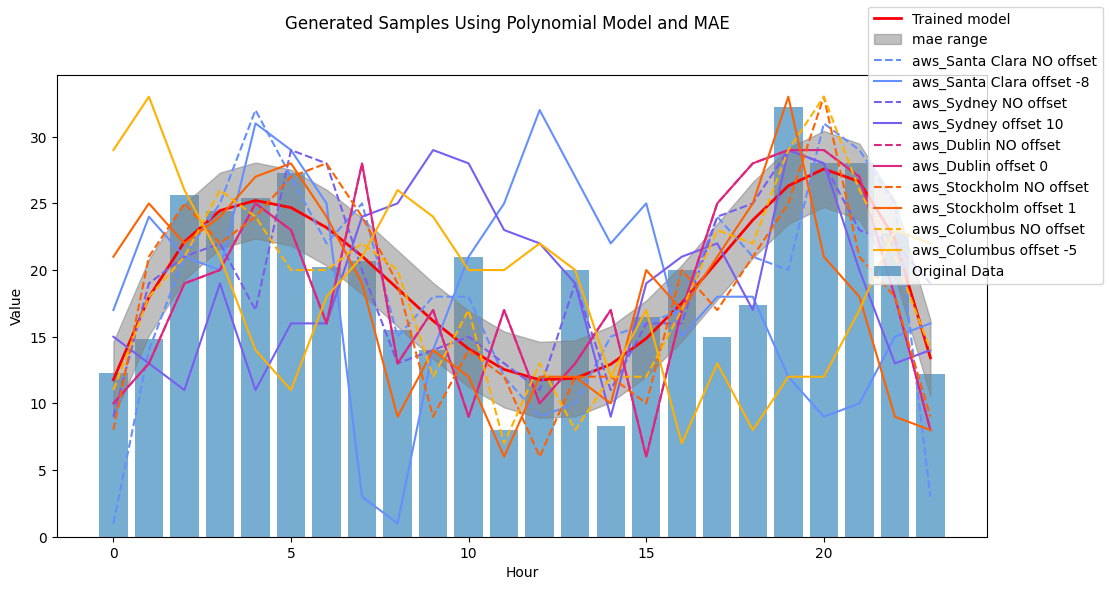

In [9]:
dataset_path = "../data/traces/spark/aws_single_node.csv"
df = pd.read_csv(dataset_path)
model, x_train, y_train, mae = get_arrival_time_distribution(df)
print(f"Mean Absolute Error: {mae}")
y_test = model(x_train)
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x_train, y_train, label='Original Data', alpha=0.6)
ax.plot(x_train, y_test, color='red', label='Trained model', linewidth=2)
ax.fill_between(x_train, y_test - mae, y_test + mae, color='gray', alpha=0.5, label='mae range')

import src.config as config 
import os

from src.plot.colors import IBM_color_blind_palette
datacenters_data_folder = f"{config.experiments_folder}/{config.d_i}-{config.d_f}/processed"
for i, dc_folder in enumerate(os.listdir(datacenters_data_folder)):
    print(f"Generating requests for {dc_folder}")
    city_timezone_offset = config.TIMEZONE_OFFSETS[dc_folder.split("_")[1]]
    arrival_time_sample = sample(model, mae, x_train)
    ax.plot(x_train, arrival_time_sample, linestyle="--", color=IBM_color_blind_palette[i], label=f'{dc_folder} NO offset')
    arrival_time_sample = arrival_time_sample[city_timezone_offset:] + arrival_time_sample[:city_timezone_offset]
    ax.plot(x_train, arrival_time_sample, color=IBM_color_blind_palette[i], label=f'{dc_folder} offset {city_timezone_offset}')
    to_concat = []
    for j, n_jobs in enumerate(arrival_time_sample):
        print(f"{j}-th hour: {timestamps_map[j]} \n\t generate {n_jobs}")
        random_indices = np.random.randint(0, len(df), n_jobs)
        sample_df = df.iloc[random_indices]
        sample_df['arrival_time'] = utils.date_to_str(timestamps_map[j])
        to_concat.append(sample_df)
    dc_requests_df = pd.concat(to_concat, axis=0)

    dc_requests_df.to_csv(f"{datacenters_data_folder}/{dc_folder}/requests.csv", index=False)


fig.suptitle('Generated Samples Using Polynomial Model and MAE')
ax.set_xlabel('Hour')
ax.set_ylabel('Value')
fig.legend()
fig.show()

In [ ]:
df.groupby(["algorithm"]).count()

In [ ]:
df.groupby(["datasize"]).count()

In [ ]:
df.groupby(["VM_instance", "algorithm", "datasize"]).runtime_sec.describe()